In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [4]:
train_df = pd.read_csv('C:\\Users\\HP\\OneDrive\\Desktop\\PAI LAB\\train.csv')
test_df = pd.read_csv('C:\\Users\\HP\\OneDrive\\Desktop\\PAI LAB\\test.csv')
print(train_df.shape)
train_df.head()

(8693, 14)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


# Exploratory Data Analysis (EDA)

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [6]:
train_df.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

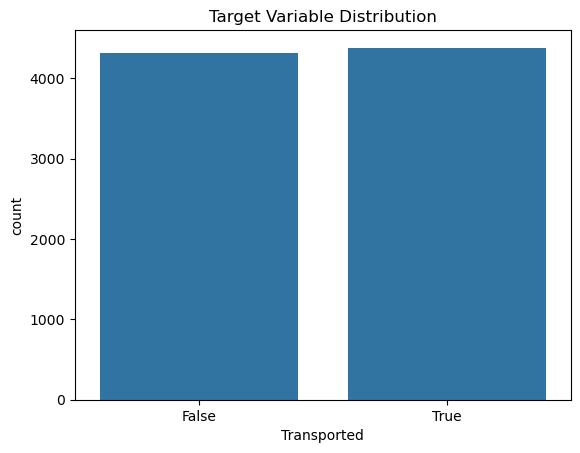

In [7]:
sns.countplot(x="Transported", data=train_df)
plt.title("Target Variable Distribution")
plt.show()

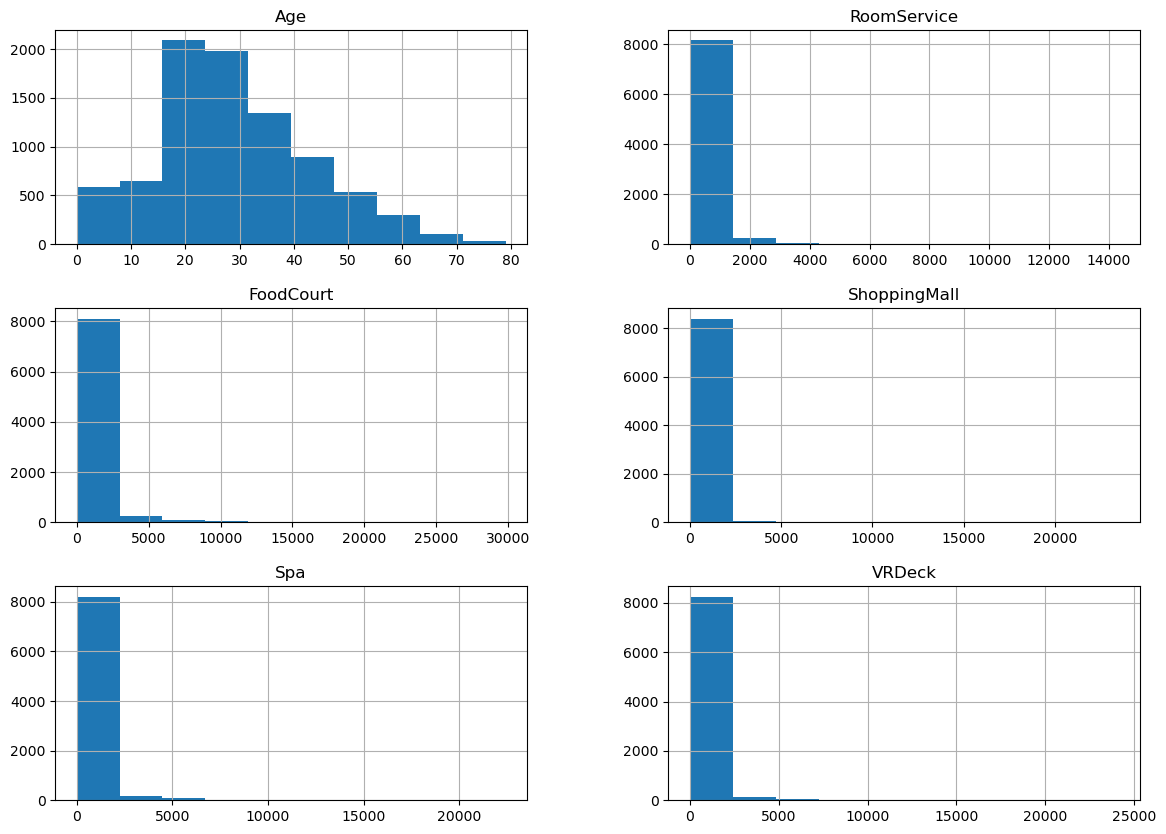

In [8]:
train_df.hist(figsize=(14,10))
plt.show()

In [9]:
train_df.drop(["PassengerId", "Name"], axis=1, inplace=True)
test_ids = test_df["PassengerId"]
test_df.drop(["PassengerId", "Name"], axis=1, inplace=True)

# split data

In [11]:
X = train_df.drop("Transported", axis=1)
y = train_df["Transported"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [13]:
# Convert categorical columns into numbers
train_df = pd.get_dummies(train_df)
test_df = pd.get_dummies(test_df)

# Align columns
train_df, test_df = train_df.align(test_df, axis=1, fill_value=0)


# Train Model (Random Forest)

In [17]:
X = train_df.drop("Transported", axis=1)
y = train_df["Transported"].astype(int)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

# Check Accuracy

In [18]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.7757331799884991


# Predict Test Data & Save File

In [21]:
test_df = test_df.drop("Transported", axis=1, errors="ignore")
test_df = test_df.drop("Transported", axis=1, errors="ignore")

test_pred = model.predict(test_df)

submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Transported": test_pred.astype(bool)
})

submission.to_csv("submission.csv", index=False)